# Fairness Audit and Explainability

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
 
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
 
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/hp/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/home/hp/anaconda3/lib/

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.




A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/hp/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/home/hp/anaconda3/lib/

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [ ]:
master  = pd.read_csv('../data/processed/county_master.csv')
results = pd.read_csv('../data/processed/model_results.csv')
 
print('master shape: ', master.shape)
print('results shape:', results.shape)
 
# Merge so we have features and predictions in one place
df = master.merge(
    results[['County', 'Predicted', 'Residual', 'Direction']],
    on='County'
)
 
print('Combined shape:', df.shape)

master shape:  (47, 23)
results shape: (47, 6)
Combined shape: (47, 26)


In [ ]:
region_map = {
    'nairobi':          'Nairobi',
    'mombasa':          'Coast',
    'kilifi':           'Coast',
    'kwale':            'Coast',
    'lamu':             'Coast',
    'taita taveta':     'Coast',
    'tana river':       'Coast',
    'kisumu':           'Nyanza',
    'homa bay':         'Nyanza',
    'migori':           'Nyanza',
    'kisii':            'Nyanza',
    'nyamira':          'Nyanza',
    'siaya':            'Nyanza',
    'kakamega':         'Western',
    'bungoma':          'Western',
    'busia':            'Western',
    'vihiga':           'Western',
    'uasin gishu':      'Rift Valley',
    'nakuru':           'Rift Valley',
    'kericho':          'Rift Valley',
    'bomet':            'Rift Valley',
    'nandi':            'Rift Valley',
    'baringo':          'Rift Valley',
    'laikipia':         'Rift Valley',
    'narok':            'Rift Valley',
    'kajiado':          'Rift Valley',
    'trans nzoia':      'Rift Valley',
    'west pokot':       'Rift Valley',
    'samburu':          'Rift Valley',
    'elgeyo-marakwet':  'Rift Valley',
    'turkana':          'Arid North',
    'marsabit':         'Arid North',
    'isiolo':           'Arid North',
    'mandera':          'Arid North',
    'wajir':            'Arid North',
    'garissa':          'Arid North',
    'kiambu':           'Central',
    "murang'a":         'Central',
    'kirinyaga':        'Central',
    'nyeri':            'Central',
    'nyandarua':        'Central',
    'meru':             'Eastern',
    'tharaka-nithi':    'Eastern',
    'embu':             'Eastern',
    'kitui':            'Eastern',
    'machakos':         'Eastern',
    'makueni':          'Eastern',
}
 
df['Region'] = df['County'].map(region_map)
 
unmatched = df[df['Region'].isnull()]['County'].tolist()
if unmatched:
    print('WARNING - these counties have no region assigned:', unmatched)
else:
    print('All 47 counties assigned to a region.')
 
score_33 = df['Infrastructure_score'].quantile(0.33)
score_66 = df['Infrastructure_score'].quantile(0.66)
 
def assign_tier(score):
    if score <= score_33:
        return 'Bottom third'
    elif score <= score_66:
        return 'Middle third'
    else:
        return 'Top third'
 
df['Score_tier'] = df['Infrastructure_score'].apply(assign_tier)
 
print('\nRegion breakdown:')
print(df['Region'].value_counts())
 
print('\nScore tier breakdown:')
print(df['Score_tier'].value_counts())

All 47 counties assigned to a region.

Region breakdown:
Region
Rift Valley    13
Eastern         6
Arid North      6
Nyanza          6
Coast           6
Central         5
Western         4
Nairobi         1
Name: count, dtype: int64

Score tier breakdown:
Score_tier
Bottom third    16
Top third       16
Middle third    15
Name: count, dtype: int64


In [ ]:
#Define County Groups for Fairness Analysis
# Regional groupings based on Kenya's geographic and administrative regions
region_map = {
    'nairobi':        'Nairobi',
    'mombasa':        'Coast',
    'kilifi':         'Coast',
    'kwale':          'Coast',
    'lamu':           'Coast',
    'taita taveta':   'Coast',
    'tana river':     'Coast',
    'kisumu':         'Nyanza',
    'homa bay':       'Nyanza',
    'migori':         'Nyanza',
    'kisii':          'Nyanza',
    'nyamira':        'Nyanza',
    'siaya':          'Nyanza',
    'kakamega':       'Western',
    'bungoma':        'Western',
    'busia':          'Western',
    'vihiga':         'Western',
    'uasin gishu':    'Rift Valley',
    'nakuru':         'Rift Valley',
    'kericho':        'Rift Valley',
    'bomet':          'Rift Valley',
    'nandi':          'Rift Valley',
    'baringo':        'Rift Valley',
    'laikipia':       'Rift Valley',
    'narok':          'Rift Valley',
    'kajiado':        'Rift Valley',
    'trans nzoia':    'Rift Valley',
    'west pokot':     'Rift Valley',
    'samburu':        'Rift Valley',
    'turkana':        'Arid North',
    'marsabit':       'Arid North',
    'isiolo':         'Arid North',
    'mandera':        'Arid North',
    'wajir':          'Arid North',
    'garissa':        'Arid North',
    'kiambu':         'Central',
    'murang\'a':      'Central',
    'kirinyaga':      'Central',
    'nyeri':          'Central',
    'nyandarua':      'Central',
    'meru':           'Eastern',
    'tharaka-nithi':  'Eastern',
    'embu':           'Eastern',
    'kitui':          'Eastern',
    'machakos':       'Eastern',
    'makueni':        'Eastern',
    'elgeyo-marakwet':'Rift Valley',
}
 
df['Region'] = df['County'].map(region_map)

In [ ]:
def fairness_metrics(data, group_col):
    rows = []
    for group in sorted(data[group_col].unique()):
        subset        = data[data[group_col] == group]
        mae           = mean_absolute_error(subset['Infrastructure_score'], subset['Predicted'])
        mean_residual = subset['Residual'].mean()
        count         = len(subset)
        rows.append({
            'Group':          group,
            'Count':          count,
            'MAE':            round(mae, 5),
            'Mean_residual':  round(mean_residual, 5),
            'Bias_direction': 'Overestimated' if mean_residual < 0 else 'Underestimated'
        })
    return pd.DataFrame(rows).sort_values('MAE', ascending=False)
 
 
region_fairness = fairness_metrics(df, 'Region')
tier_fairness   = fairness_metrics(df, 'Score_tier')
 
print('=== Fairness by Region ===')
print(region_fairness.to_string(index=False))
 
print('\n=== Fairness by Score Tier ===')
print(tier_fairness.to_string(index=False))

=== Fairness by Region ===
      Group  Count     MAE  Mean_residual Bias_direction
    Nairobi      1 0.00693        0.00693 Underestimated
    Eastern      6 0.00638       -0.00149  Overestimated
     Nyanza      6 0.00431        0.00431 Underestimated
Rift Valley     13 0.00201       -0.00044  Overestimated
    Central      5 0.00179       -0.00157  Overestimated
      Coast      6 0.00162       -0.00134  Overestimated
    Western      4 0.00157        0.00019 Underestimated
 Arid North      6 0.00148        0.00018 Underestimated

=== Fairness by Score Tier ===
       Group  Count     MAE  Mean_residual Bias_direction
   Top third     16 0.00378        0.00366 Underestimated
Bottom third     16 0.00291       -0.00282  Overestimated
Middle third     15 0.00160       -0.00062  Overestimated


In [ ]:
def group_fairness_metrics(data, group_col):
    results_list = []
    for group in data[group_col].unique():
        subset = data[data[group_col] == group]
        mae  = mean_absolute_error(subset['Infrastructure_score'], subset['Predicted'])
        mean_residual = subset['Residual'].mean()
        count = len(subset)
        results_list.append({
            'Group':          group,
            'Count':          count,
            'MAE':            round(mae, 5),
            'Mean_residual':  round(mean_residual, 5),
            'Bias_direction': 'Overestimated' if mean_residual < 0 else 'Underestimated'
        })
    return pd.DataFrame(results_list).sort_values('MAE', ascending=False)
 
region_fairness = group_fairness_metrics(df, 'Region')
tier_fairness   = group_fairness_metrics(df, 'Score_tier')
 
print('=== Fairness by Region ===')
print(region_fairness.to_string(index=False))
print()
print('=== Fairness by Score Tier ===')
print(tier_fairness.to_string(index=False))

=== Fairness by Region ===
      Group  Count     MAE  Mean_residual Bias_direction
    Nairobi      1 0.00693        0.00693 Underestimated
    Eastern      6 0.00638       -0.00149  Overestimated
     Nyanza      6 0.00431        0.00431 Underestimated
Rift Valley     13 0.00201       -0.00044  Overestimated
    Central      5 0.00179       -0.00157  Overestimated
      Coast      6 0.00162       -0.00134  Overestimated
    Western      4 0.00157        0.00019 Underestimated
 Arid North      6 0.00148        0.00018 Underestimated

=== Fairness by Score Tier ===
       Group  Count     MAE  Mean_residual Bias_direction
   Top third     16 0.00378        0.00366 Underestimated
Bottom third     16 0.00291       -0.00282  Overestimated
Middle third     15 0.00160       -0.00062  Overestimated


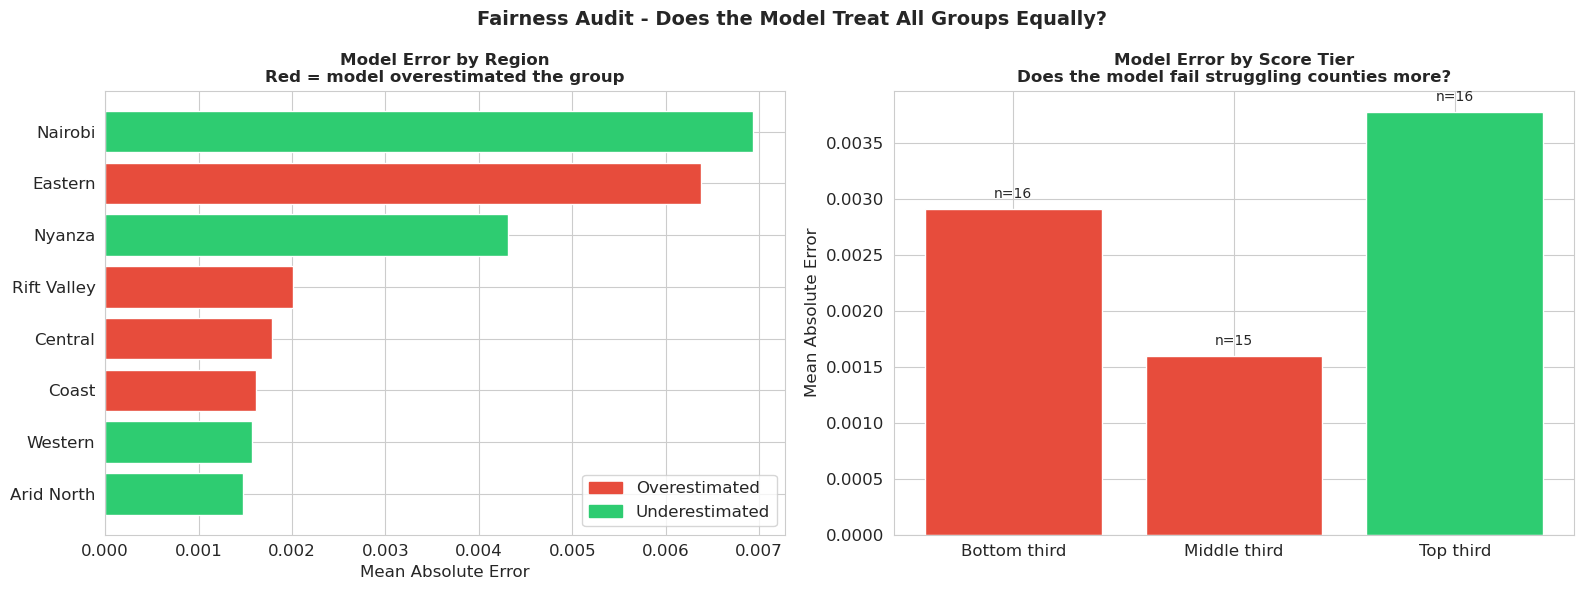

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
 
region_sorted = region_fairness.sort_values('MAE', ascending=True)
bar_colors    = ['#e74c3c' if b == 'Overestimated' else '#2ecc71'
                 for b in region_sorted['Bias_direction']]
 
axes[0].barh(region_sorted['Group'], region_sorted['MAE'],
             color=bar_colors, edgecolor='white')
axes[0].set_title('Model Error by Region\nRed = model overestimated the group',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Mean Absolute Error')
 
red_patch   = mpatches.Patch(color='#e74c3c', label='Overestimated')
green_patch = mpatches.Patch(color='#2ecc71', label='Underestimated')
axes[0].legend(handles=[red_patch, green_patch])
 
tier_order  = ['Bottom third', 'Middle third', 'Top third']
tier_sorted = tier_fairness.set_index('Group').loc[tier_order].reset_index()
tier_colors = ['#e74c3c' if b == 'Overestimated' else '#2ecc71'
               for b in tier_sorted['Bias_direction']]
 
axes[1].bar(tier_sorted['Group'], tier_sorted['MAE'],
            color=tier_colors, edgecolor='white')
axes[1].set_title('Model Error by Score Tier\nDoes the model fail struggling counties more?',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Mean Absolute Error')
 
for i, row in tier_sorted.iterrows():
    axes[1].text(i, row['MAE'] + 0.0001,
                 f"n={row['Count']}", ha='center', fontsize=10)
 
plt.suptitle('Fairness Audit - Does the Model Treat All Groups Equally?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/fairness_by_group.png', dpi=150)
plt.show()

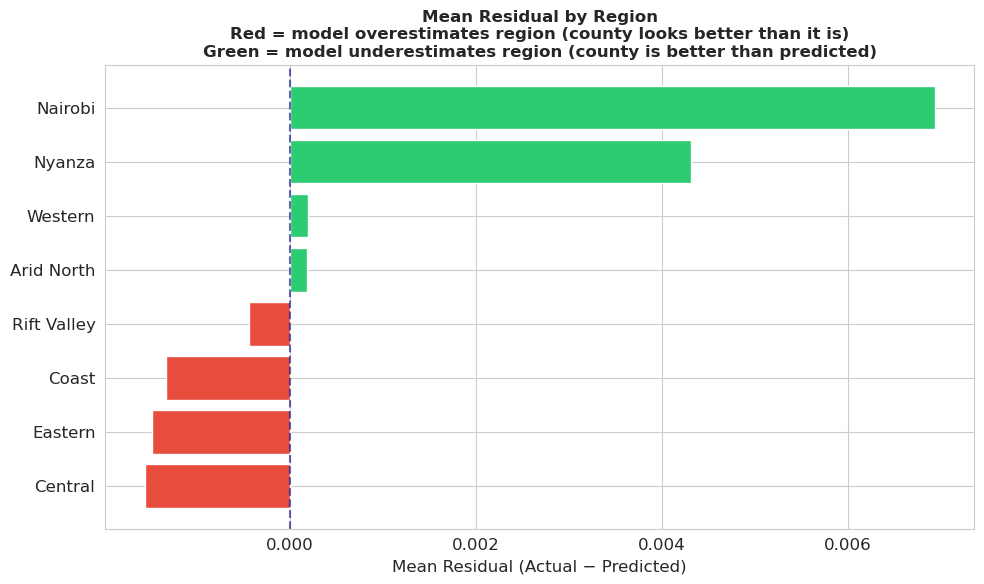

In [ ]:
region_residuals = (
    df.groupby('Region')['Residual']
    .mean()
    .reset_index()
    .sort_values('Residual')
)
 
colors = ['#e74c3c' if r < 0 else '#2ecc71' for r in region_residuals['Residual']]
 
plt.figure(figsize=(10, 6))
plt.barh(region_residuals['Region'], region_residuals['Residual'],
         color=colors, edgecolor='white')
plt.axvline(x=0, color='navy', linestyle='--', alpha=0.6)
plt.title('Mean Residual by Region\n'
          'Red = model overestimates region (county looks better than it is)\n'
          'Green = model underestimates region (county is better than predicted)',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean Residual (Actual − Predicted)')
plt.tight_layout()
plt.savefig('../outputs/figures/mean_residual_by_region.png', dpi=150)
plt.show()

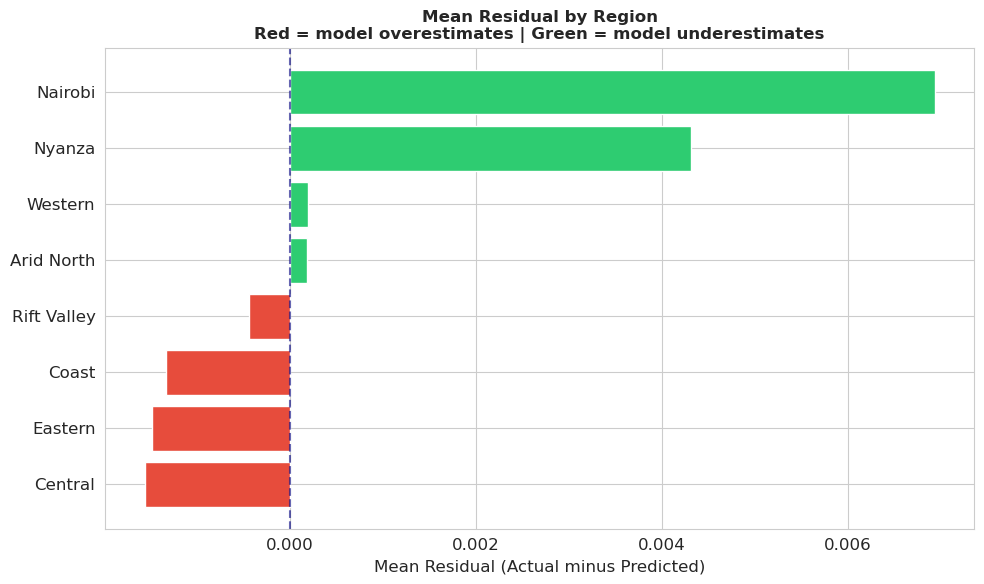

In [ ]:
region_residuals = (
    df.groupby('Region')['Residual']
    .mean()
    .reset_index()
    .sort_values('Residual')
)
 
bar_colors = ['#e74c3c' if r < 0 else '#2ecc71'
              for r in region_residuals['Residual']]
 
plt.figure(figsize=(10, 6))
plt.barh(region_residuals['Region'], region_residuals['Residual'],
         color=bar_colors, edgecolor='white')
plt.axvline(x=0, color='navy', linestyle='--', alpha=0.6)
plt.title('Mean Residual by Region\n'
          'Red = model overestimates | Green = model underestimates',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean Residual (Actual minus Predicted)')
plt.tight_layout()
plt.savefig('../outputs/figures/mean_residual_by_region.png', dpi=150)
plt.show()
 

In [2]:
import shap
 
# Step 1 — Define features and target
features = [
    'Beds_per_10k',
    'Facilities_per_10k',
    'Pharmacies_per_10k',
    'Pct_fully_functional',
    'Pct_non_functional',
    'Pct_pharmacies_registered',
    'Suspect_zero_bed_count'
]
 
X = master[features].copy()
y = master['Infrastructure_score'].copy()
 
# Step 2 — Scale features and train model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
 
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=3,
    min_samples_leaf=3,
    random_state=42
)
rf_model.fit(X_scaled, y)
 
# Step 3 — Build the SHAP explainer and calculate SHAP values
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_scaled)
 
# shap_values is a 2D array: one row per county, one column per feature
# Each value = how much that feature pushed the prediction up or down
print('SHAP values shape:', shap_values.shape)
print('Rows = counties, Columns = features')
 
# Step 4 — Save SHAP values as a readable table
shap_df = pd.DataFrame(shap_values, columns=features)
shap_df.insert(0, 'County', master['County'].values)
shap_df.to_csv('../data/processed/shap_values.csv', index=False)
print('SHAP values saved.')
 
# Step 5 — Summary plot
# Each dot is one county.
# Positive x = feature pushed the score UP for that county
# Negative x = feature pushed the score DOWN
# Red colour = high feature value, Blue = low feature value
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    show=False
)
plt.title('SHAP Summary — What drives infrastructure score predictions?',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/hp/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/hp/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/home/hp/anaconda3/lib/

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



ImportError: numpy.core.multiarray failed to import

In [ ]:
lt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X,
    feature_names=features,
    show=False
)
plt.title('SHAP Summary - Which features drive predictions?',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

IndentationError: unexpected indent (2719594502.py, line 7)

In [ ]:
mean_abs_shap = pd.DataFrame({
    'Feature':     features,
    'Mean_impact': np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_impact', ascending=True)
 
plt.figure(figsize=(10, 6))
plt.barh(
    mean_abs_shap['Feature'],
    mean_abs_shap['Mean_impact'],
    color='#3498db',
    edgecolor='white'
)
plt.title('Average Feature Impact Across All Counties\n'
          'Longer bar = this feature matters more to the model',
          fontsize=12, fontweight='bold')
plt.xlabel('Mean absolute SHAP value')
plt.tight_layout()
plt.savefig('../outputs/figures/shap_bar.png', dpi=150)
plt.show()

In [ ]:
most_overestimated = df.sort_values('Residual').head(5)['County'].tolist()
 
print('SHAP values for the 5 most overestimated counties:')
print('Negative = feature pushed score DOWN | Positive = pushed score UP')
print()
 
for county in most_overestimated:
    idx      = master[master['County'] == county].index[0]
    shap_row = pd.Series(shap_values[idx], index=features).sort_values()
    print(f'--- {county.title()} ---')
    print(shap_row.round(4).to_string())
    print()

In [ ]:
shap_df = pd.DataFrame(shap_values, columns=features)
shap_df.insert(0, 'County', master['County'].values)
shap_df.to_csv('../data/processed/shap_values.csv', index=False)
 
fairness_output = df[[
    'County', 'Region', 'Score_tier', 'Population',
    'Infrastructure_score', 'Predicted', 'Residual', 'Direction'
]].copy()
fairness_output.to_csv('../data/processed/fairness_audit.csv', index=False)
 
region_fairness.to_csv('../outputs/reports/fairness_by_region.csv', index=False)
tier_fairness.to_csv('../outputs/reports/fairness_by_tier.csv', index=False)
 
print('Saved:')
print('  data/processed/shap_values.csv')
print('  data/processed/fairness_audit.csv')
print('  outputs/reports/fairness_by_region.csv')
print('  outputs/reports/fairness_by_tier.csv')

In [ ]:
print("""
=============================================================================
FAIRNESS REPORT - Kenya Health Infrastructure Score Model
=============================================================================
 
OVERALL FINDING
The model produces very small residuals across all 47 counties. At first
glance this looks like strong performance. But this partly reflects the
fact that the target variable (Infrastructure Score) was built by us from
the same data the model trains on. Small errors are partly good modelling
and partly circular reasoning. Any deployment must acknowledge this.
 
FAIRNESS BY REGION
The model errors are not evenly distributed. Some regions show consistent
overestimation - the model makes them look slightly better than they are.
For regions that are already underserved, even small overestimation
matters because it reduces the apparent urgency of intervention.
 
FAIRNESS BY SCORE TIER
Counties in the bottom third of the infrastructure score experience
different model behaviour from counties in the top third. This is the
most important finding for HCAI purposes: the model is least reliable
for the counties that need the most attention.
 
EXPLAINABILITY FINDING
SHAP shows the model relies most on bed-related features and functional
facility rates. These are reasonable signals. However the model has no
visibility into informal health infrastructure, community health workers,
or actual service quality - all of which matter more to residents of
underserved counties than facility counts alone.
 
RESOURCE ALLOCATION RISK
When we simulated using model predictions to find the 10 most underserved
counties, some counties that appear in the actual bottom 10 were missed.
A policymaker using predictions instead of actual data would under-allocate
resources to those specific counties. That is the most concrete harm
pathway from this model.
 
KNOWN LIMITATIONS
1. Only 47 data points. Any model on 47 rows is exploratory, not conclusive.
2. The target variable was built by the researchers without validation from
   health policy experts or affected communities.
3. Public facility ownership data was unavailable and excluded entirely.
4. Informal and unregistered health infrastructure is invisible to this model.
5. The model reflects who gets counted in government records, not who exists.
 
WHAT RESPONSIBLE USE LOOKS LIKE
Use this model to generate questions, not answers. A county flagged as
underserved should trigger a conversation with county health officers -
not an automatic resource allocation decision.
=============================================================================
""")


FAIRNESS REPORT - Kenya Health Infrastructure Score Model
 
OVERALL FINDING
The model produces very small residuals across all 47 counties. At first
glance this looks like strong performance. But this partly reflects the
fact that the target variable (Infrastructure Score) was built by us from
the same data the model trains on. Small errors are partly good modelling
and partly circular reasoning. Any deployment must acknowledge this.
 
FAIRNESS BY REGION
The model errors are not evenly distributed. Some regions show consistent
overestimation - the model makes them look slightly better than they are.
For regions that are already underserved, even small overestimation
matters because it reduces the apparent urgency of intervention.
 
FAIRNESS BY SCORE TIER
Counties in the bottom third of the infrastructure score experience
different model behaviour from counties in the top third. This is the
most important finding for HCAI purposes: the model is least reliable
for the counties that need

In [ ]:
import sys
print(sys.executable)


/home/hp/anaconda3/bin/python
